# MODELIZACIÓN CLASIFICACIÓN PROBABILITY OF DEFAULT

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

In [2]:
df = pd.read_pickle('../02_datos/03_Entrenamiento/df_tablon_pd.pkl')

In [3]:
x = df.drop(columns='target_pd')
y = df.target_pd

## MODELIZAR

### Reservar el dataset de validacion

In [4]:
from sklearn.model_selection import train_test_split
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([('algoritmo',LogisticRegression())])

grid = [{'algoritmo': [LogisticRegression(solver = 'saga')],
         'algoritmo__l1_ratio': [0, 0.5, 1],
         'algoritmo__C': [0.01,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

####  Con grid search

In [6]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator= pipe, 
                           param_grid = grid, 
                           cv = 5, 
                           scoring = 'roc_auc',
                           verbose = 0,
                           n_jobs = -1)

modelo = grid_search.fit(train_x,train_y)

In [7]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(5)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.308,0.426,0.030,0.006,LogisticRegression(solver='saga'),1.000,1.000,{'algoritmo': LogisticRegression(solver='saga'...,0.708,0.696,0.697,0.700,0.702,0.701,0.004,1
1,11.963,0.968,0.027,0.009,LogisticRegression(solver='saga'),1.000,0.500,{'algoritmo': LogisticRegression(solver='saga'...,0.708,0.696,0.697,0.700,0.702,0.701,0.004,2
2,3.307,0.232,0.037,0.013,LogisticRegression(solver='saga'),0.750,1.000,{'algoritmo': LogisticRegression(solver='saga'...,0.708,0.696,0.697,0.700,0.702,0.701,0.004,3
3,10.740,0.278,0.035,0.006,LogisticRegression(solver='saga'),1.000,0.000,{'algoritmo': LogisticRegression(solver='saga'...,0.708,0.696,0.697,0.700,0.702,0.701,0.004,4
4,11.347,0.745,0.032,0.002,LogisticRegression(solver='saga'),0.750,0.500,{'algoritmo': LogisticRegression(solver='saga'...,0.708,0.696,0.697,0.700,0.702,0.701,0.004,5


El resultado del auc es el mismo en todas las primeras configuraciones.

reentreno el modelo con esa configuración.

In [8]:
#Instanciar
rl = LogisticRegression(solver = 'saga', C = 1, l1_ratio = 1)
#Entrenar
rl.fit(train_x,train_y)

,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization stren

Podemos revisar los coefecientes para ver los que son cero y las variables más importantes.

In [9]:
coeficientes = pd.DataFrame(data = rl.coef_, columns = rl.feature_names_in_).stack().droplevel(level = 0).sort_values()
coeficientes

tipo_interes_mms                       -2.466
ingresos_mms                           -1.492
principal_mms                          -1.344
finalidad_house                        -0.342
ingresos_verificados_Not Verified      -0.263
num_cuotas_ 36 months                  -0.254
finalidad_other                        -0.129
finalidad_car                          -0.126
finalidad_vacation                     -0.093
vivienda_MORTGAGE                      -0.089
finalidad_credit_card                  -0.065
antigüedad_empleo_oe_mms               -0.056
vivienda_OWN                            0.000
dti_mms                                 0.000
ingresos_verificados_Source Verified    0.000
finalidad_debt_consolidation            0.000
num_cuotas_ 60 months                   0.007
finalidad_medical                       0.019
finalidad_home_improvement              0.022
ingresos_verificados_Verified           0.112
finalidad_major_purchase                0.115
finalidad_moving                  

## EVALUAR

### Predecir sobre validación

In [10]:
pred = rl.predict_proba(val_x)[:, 1]

### Evaluar sobre validación

In [11]:
from sklearn.metrics import roc_auc_score
roc_auc_score(val_y, pred)

0.6994251804003387

## REPORTING DEL MODELO

### Gain Chart

In [12]:
def gain_chart(y_true, y_pred, figsize=(8, 6)):
    df_gain = pd.DataFrame({'y': y_true, 'pred': y_pred})
    df_gain = df_gain.sort_values('pred', ascending=False).reset_index(drop=True)

    df_gain['acumulado'] = df_gain['y'].cumsum() / df_gain['y'].sum()
    df_gain['porcentaje_muestra'] = (np.arange(len(df_gain)) + 1) / len(df_gain)

    plt.figure(figsize=figsize)
    plt.plot(df_gain['porcentaje_muestra'], df_gain['acumulado'], label='Modelo')
    plt.plot(df_gain['porcentaje_muestra'], df_gain['porcentaje_muestra'], '--', label='Aleatorio')
    plt.xlabel('Porcentaje de muestra')
    plt.ylabel('Porcentaje acumulado de positivos')
    plt.title('Gain Chart')
    plt.legend()
    plt.grid()
    plt.show()

    return df_gain



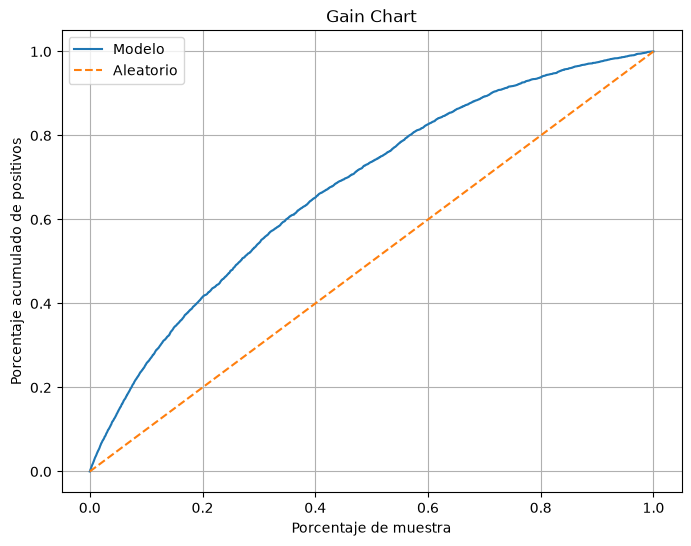

,y,pred,acumulado,porcentaje_muestra
0,0,0.752,0.000,0.000
1,1,0.717,0.000,0.000
2,0,0.712,0.000,0.000
3,0,0.706,0.000,0.000
4,1,0.674,0.000,0.000
...,...,...,...,...
41876,0,0.015,1.000,1.000
41877,0,0.015,1.000,1.000
41878,0,0.015,1.000,1.000
41879,0,0.014,1.000,1.000


In [13]:
gain_chart(val_y, pred)

### Lift Chart

In [14]:
def lift_chart(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'pred': y_pred})
    df = df.sort_values('pred', ascending=False).reset_index(drop=True)
    total_positivos = df['y'].sum()
    total_muestra = len(df)
    porcentaje_muestra = np.arange(1, total_muestra + 1) / total_muestra
    acumulado_positivos = df['y'].cumsum()
    lift_acumulado = (acumulado_positivos / porcentaje_muestra) / total_positivos

    plt.figure(figsize=(8,6))
    plt.plot(porcentaje_muestra, lift_acumulado, label='Modelo', color='green')
    plt.axhline(1, color='black', linestyle='--', label='Aleatorio')
    plt.xlabel('Porcentaje de muestra')
    plt.ylabel('Lift acumulado')
    plt.title('Lift Curve')
    plt.legend()
    plt.grid()
    plt.show()

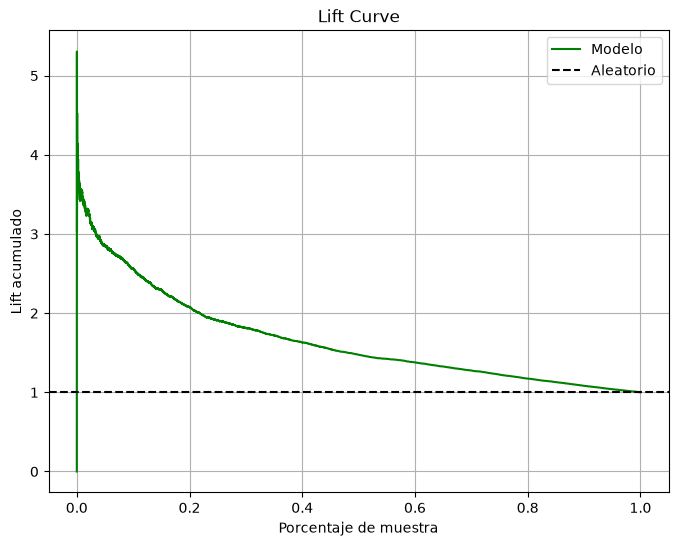

In [15]:
lift_chart(val_y, pred)

### ROC Chart

In [16]:
def roc_curve(y_true, y_pred, n_thresholds=100):
    df = pd.DataFrame({'y': y_true, 'pred': y_pred})
    thresholds = np.linspace(0, 1, n_thresholds)
    tpr = []
    fpr = []
    total_pos = (df['y'] == 1).sum()
    total_neg = (df['y'] == 0).sum()
    for thresh in thresholds:
        y_pred_bin = (df['pred'] >= thresh).astype(int)
        tp = ((df['y'] == 1) & (y_pred_bin == 1)).sum()
        fp = ((df['y'] == 0) & (y_pred_bin == 1)).sum()
        tpr.append(tp / total_pos if total_pos > 0 else 0)
        fpr.append(fp / total_neg if total_neg > 0 else 0)
    tpr = np.array(tpr)
    fpr = np.array(fpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='green', label='Modelo')
    plt.plot([0,1], [0,1], '--', color='black', label='Aleatorio')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid()
    plt.show()

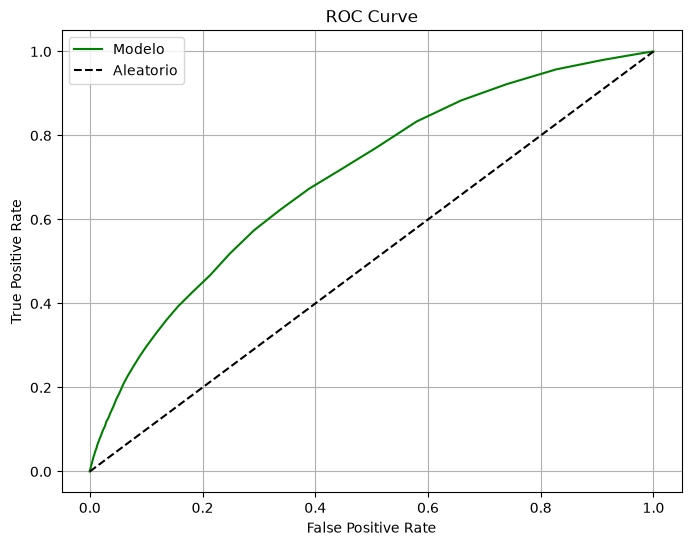

In [17]:
roc_curve(val_y, pred)